---
title: "N4: Introduction to Machine Learning — Random Forest Regression"
toc: true
toc-depth: 3
---

<a href="https://colab.research.google.com/github/cmg777/claude4data/blob/master/notebooks/notebook-04.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

## 1. Introduction

This notebook introduces machine learning through a practical application: predicting Bolivia's Municipal Sustainable Development Index (IMDS) from satellite image embeddings using Random Forest regression. IMDS is a composite index (0–100 scale) that captures how well each of Bolivia's 339 municipalities is progressing toward sustainable development goals. Satellite embeddings are 64-dimensional feature vectors extracted from 2017 satellite imagery — they compress visual information about land use, urbanization, and terrain into numbers a model can learn from.

The distinctive feature of this notebook is **how** we evaluate the model. Instead of a single 80/20 train/test split, we use **5-fold cross-validation** so that every municipality receives an honest, *out-of-fold* prediction — a prediction made by a forest that never saw it during training. The train/test split and hyperparameter tuning are deferred to the appendices.

**Learning objectives:**

- Explain how a Random Forest works (decision trees, bagging, random feature subsets).
- Motivate *why* a single train/test split is unreliable on a small dataset, and what k-fold cross-validation does instead.
- Generate out-of-fold predictions with `cross_val_predict`.
- Report performance as a mean ± standard deviation across folds, and explain why the standard deviation matters.
- Compare the distribution of predictions to the distribution of actual values.
- Interpret MDI and permutation feature importance and partial dependence plots.
- Decide when hyperparameter tuning is worth the effort (Appendix B).

In [1]:
import sys
if "google.colab" in sys.modules:
    !git clone --depth 1 https://github.com/cmg777/claude4data.git /content/claude4data 2>/dev/null || true
    %cd /content/claude4data/notebooks
    !pip install -q optuna
sys.path.insert(0, "..")
from config import set_seeds, RANDOM_SEED, IMAGES_DIR, TABLES_DIR, DATA_DIR

set_seeds()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, ks_2samp
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from IPython.display import Markdown

# Configuration
TARGET = "imds"
TARGET_LABEL = "IMDS (Municipal Sustainable Development Index)"
FEATURE_COLS = [f"A{i:02d}" for i in range(64)]
N_FOLDS = 5

# Site palette + two extra fold colors so all five folds are distinguishable
COLOR_PRIMARY, COLOR_ACCENT, COLOR_DARK, COLOR_TEAL = "#6a9bcc", "#d97757", "#141413", "#00d4c8"
FOLD_COLORS = ["#6a9bcc", "#d97757", "#00d4c8", "#8e6fb0", "#e0a23a"]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 11,
})

def rmse(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(np.sqrt(np.mean((a - b) ** 2)))

DS4BOLIVIA_BASE = "https://raw.githubusercontent.com/quarcs-lab/ds4bolivia/master"
CACHE_PATH = DATA_DIR / "rawData" / "ds4bolivia_merged.csv"

## 2. Data

### 2.1 Loading and merging the data

The data come from the [DS4Bolivia](https://github.com/quarcs-lab/ds4bolivia) repository. We merge three tables on `asdf_id` — the unique municipality identifier: SDG indices (the target), satellite embeddings (the features), and region names (context).

In [3]:
if CACHE_PATH.exists():
    df = pd.read_csv(CACHE_PATH)
else:
    sdg = pd.read_csv(f"{DS4BOLIVIA_BASE}/sdg/sdg.csv")
    embeddings = pd.read_csv(f"{DS4BOLIVIA_BASE}/satelliteEmbeddings/satelliteEmbeddings2017.csv")
    regions = pd.read_csv(f"{DS4BOLIVIA_BASE}/regionNames/regionNames.csv")
    df = sdg.merge(embeddings, on="asdf_id").merge(regions, on="asdf_id")
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE_PATH, index=False)

X = df[FEATURE_COLS]
y = df[TARGET]
mask = X.notna().all(axis=1) & y.notna()
X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Observations after dropping missing: {len(y)}")
print(y.describe().round(2))

Dataset shape: (339, 88)
Observations after dropping missing: 339
count    339.00
mean      51.05
std        6.77
min       35.70
25%       47.00
50%       50.50
75%       54.85
max       80.20
Name: imds, dtype: float64


### 2.2 The target and the features

All 339 municipalities load with no missing values. IMDS scores range from 35.70 to 80.20 with a mean of 51.05 and standard deviation of 6.77 — most municipalities cluster within about 7 points of the national average. Keep that 6.77 in mind: it is the yardstick for our errors and the spread the model will try, and partly fail, to reproduce.

## 3. Exploratory data analysis

### 3.1 Target distribution

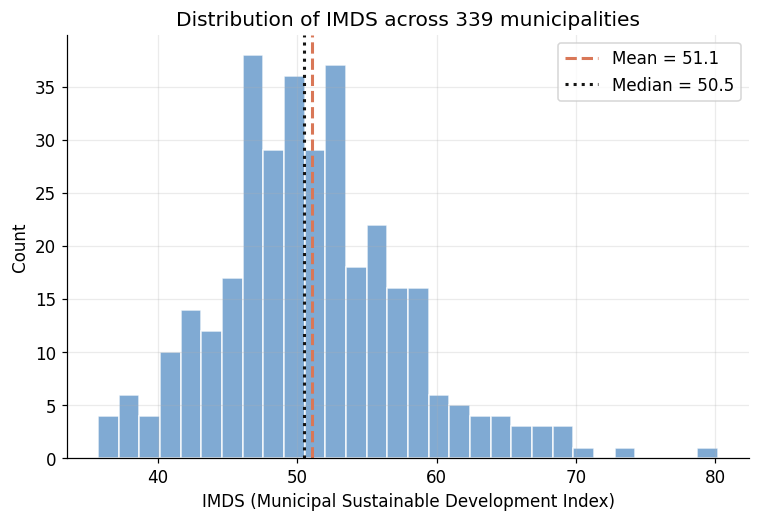

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y, bins=30, edgecolor="white", alpha=0.85, color=COLOR_PRIMARY)
ax.axvline(y.mean(), color=COLOR_ACCENT, linestyle="--", linewidth=2, label=f"Mean = {y.mean():.1f}")
ax.axvline(y.median(), color=COLOR_DARK, linestyle=":", linewidth=2, label=f"Median = {y.median():.1f}")
ax.set_xlabel(TARGET_LABEL); ax.set_ylabel("Count")
ax.set_title("Distribution of IMDS across 339 municipalities")
ax.legend()
plt.savefig(IMAGES_DIR / "ml_target_distribution.png")
plt.show()

The distribution is roughly bell-shaped with a slight right skew — the mean (51.1) sits just above the median (50.5). Most scores fall between 47 and 55; the handful of outliers above 70 are larger urban centers like La Paz, Santa Cruz, and Cochabamba. These extremes are exactly the municipalities a low-signal model will struggle with.

### 3.2 Embedding correlations

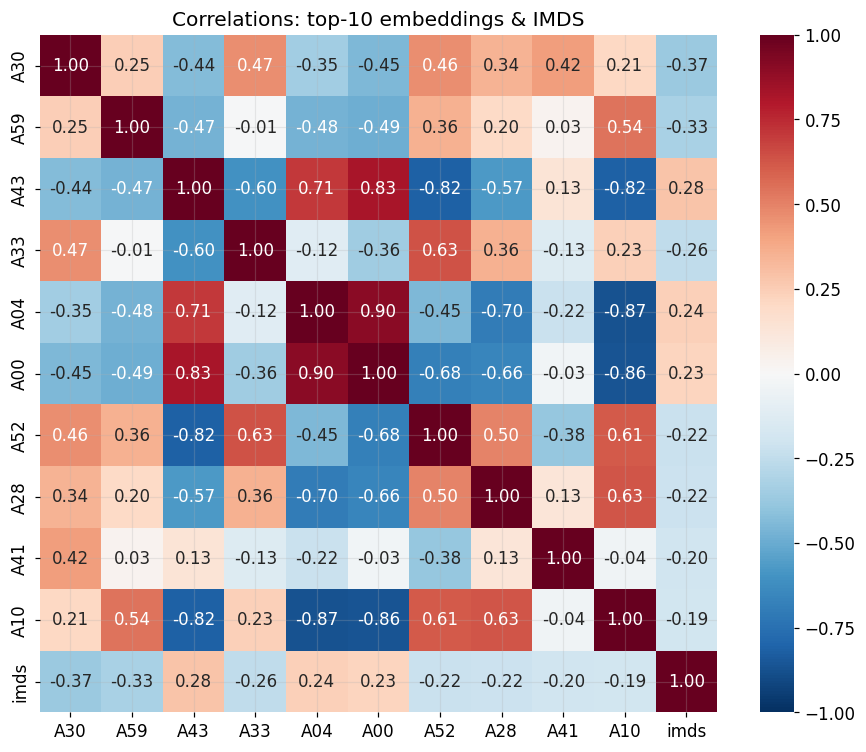

In [5]:
correlations = X.corrwith(y).abs().sort_values(ascending=False)
top10_features = correlations.head(10).index.tolist()
corr_matrix = df.loc[mask, top10_features + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlations: top-10 embeddings & IMDS")
plt.savefig(IMAGES_DIR / "ml_embedding_correlations.png")
plt.show()

The strongest single correlation is about 0.37 (dimension A30); the rest of the top ten sit in the 0.25–0.35 range. These are *moderate* correlations — an early hint that no single feature will carry the model. A Random Forest handles the multicollinearity among embeddings gracefully because it selects feature subsets at each split.

## 4. The baseline Random Forest model

A **Random Forest** averages many decision trees, each grown on a bootstrap sample with random feature subsets:

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

Each tree $T_b$ sees different rows and features, so the trees make different errors and averaging cancels much of the noise. $B$ is `n_estimators` (100 by default). We keep scikit-learn's defaults — the honest reference point. (Appendix B confirms tuning barely helps here.)

In [6]:
baseline_rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)

## 5. Cross-validation: a better way to test predictions

### 5.1 Why not just one train/test split?

With only 339 municipalities, a 20% test set is just 68 points, and the score depends heavily on which municipalities land in it — the estimate is noisy and wastes data. Appendix A shows that across 200 random splits the test R² wanders from about −0.09 to 0.46 for the *same model on the same data*.

### 5.2 What is k-fold cross-validation?

Shuffle the data into $k$ folds and run $k$ rounds: each round holds out one fold and trains on the other $k-1$. Every observation is tested exactly once. We use $k = 5$ and score three metrics at once. (scikit-learn reports RMSE and MAE as negative numbers so "higher is better" holds for every scorer; we flip the sign.)

In [7]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv = cross_validate(
    baseline_rf, X, y, cv=kf,
    scoring=("r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"),
)
fold_r2   = cv["test_r2"]
fold_rmse = -cv["test_neg_root_mean_squared_error"]
fold_mae  = -cv["test_neg_mean_absolute_error"]

print("Per-fold R²:", fold_r2.round(3))
print(f"Mean R²: {fold_r2.mean():.3f} ± {fold_r2.std():.3f}")

Per-fold R²: [ 0.209  0.121 -0.032  0.453  0.367]
Mean R²: 0.224 ± 0.173


### 5.3 Out-of-fold predictions for every municipality

`cross_val_predict` runs the same five rounds and records the prediction for each held-out fold, producing one out-of-fold (OOF) prediction per municipality. We pass the *same* `kf` so the folds match the metrics above, and we record each point's fold.

In [8]:
oof_pred = cross_val_predict(baseline_rf, X, y, cv=kf)

fold_id = np.empty(len(y), dtype=int)
for k, (_, test_idx) in enumerate(kf.split(X), start=1):
    fold_id[test_idx] = k

pooled_r2 = r2_score(y, oof_pred)
print(f"Out-of-fold predictions: {len(oof_pred)} municipalities")
print(f"Pooled out-of-fold R²:   {pooled_r2:.3f}")

Out-of-fold predictions: 339 municipalities
Pooled out-of-fold R²:   0.225


## 6. Evaluating predictions across folds

### 6.1 Per-fold performance metrics

In [9]:
fold_table = pd.DataFrame({
    "Fold": list(range(1, N_FOLDS + 1)) + ["Mean", "Std"],
    "n": [int((fold_id == k).sum()) for k in range(1, N_FOLDS + 1)] + ["", ""],
    "R2": list(fold_r2.round(3)) + [round(fold_r2.mean(), 3), round(fold_r2.std(), 3)],
    "RMSE": list(fold_rmse.round(2)) + [round(fold_rmse.mean(), 2), round(fold_rmse.std(), 2)],
    "MAE": list(fold_mae.round(2)) + [round(fold_mae.mean(), 2), round(fold_mae.std(), 2)],
})
fold_table.to_csv(TABLES_DIR / "ml_cv_fold_metrics.csv", index=False)
Markdown(fold_table.to_markdown(index=False))

| Fold   | n   |     R2 |   RMSE |   MAE |
|:-------|:----|-------:|-------:|------:|
| 1      | 68  |  0.209 |   6.61 |  4.73 |
| 2      | 68  |  0.121 |   7.34 |  5.05 |
| 3      | 68  | -0.032 |   5.73 |  4.43 |
| 4      | 68  |  0.453 |   4.49 |  3.82 |
| 5      | 67  |  0.367 |   5.14 |  4.05 |
| Mean   |     |  0.224 |   5.86 |  4.42 |
| Std    |     |  0.173 |   1.01 |  0.44 |

Look at the R² column. Fold 4 reaches about 0.45 while fold 3 comes in *negative* — on those 68 municipalities the forest did slightly worse than predicting the national average. Same model, same data; only the luck of the fold differs. This is the most important table in the notebook.

### 6.2 Why the standard deviation matters

Reporting only "R² = 0.22" would hide the most important part: the standard deviation (≈ 0.17) is almost as large as the mean. A single split would have handed us one of these numbers with no way to know which. The figure shows each metric fold-by-fold with the mean (dashed) and a ±1 SD band.

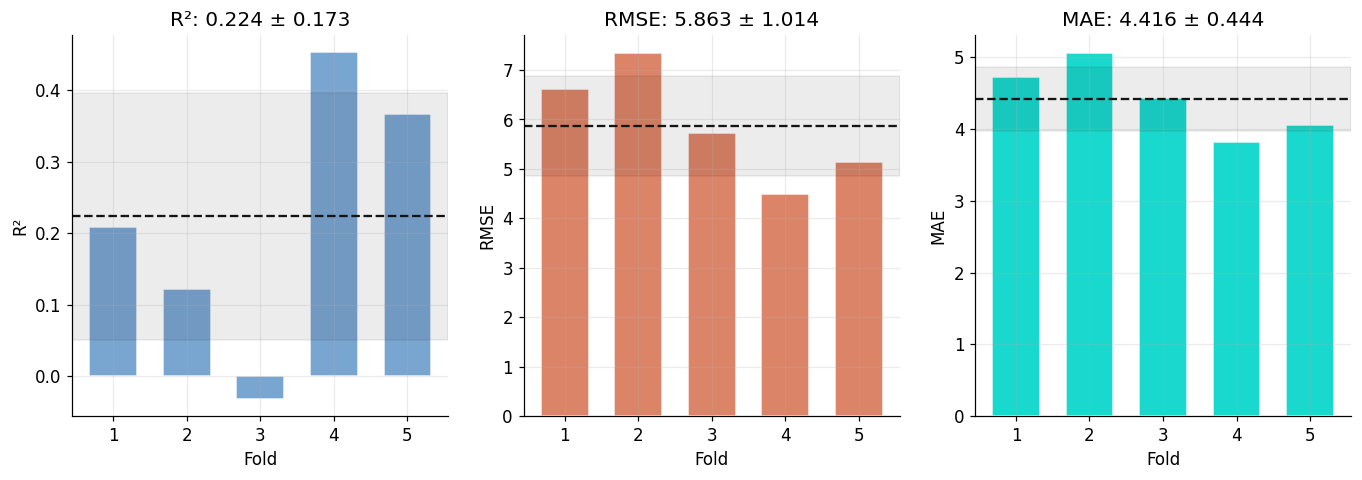

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
folds = np.arange(1, N_FOLDS + 1)
for ax, (name, vals, color) in zip(axes, [
        ("R²", fold_r2, COLOR_PRIMARY), ("RMSE", fold_rmse, COLOR_ACCENT), ("MAE", fold_mae, COLOR_TEAL)]):
    ax.bar(folds, vals, color=color, edgecolor="white", alpha=0.9, width=0.65)
    m, s = vals.mean(), vals.std()
    ax.axhspan(m - s, m + s, color=COLOR_DARK, alpha=0.08)
    ax.axhline(m, color=COLOR_DARK, linestyle="--", linewidth=1.5)
    ax.set_xticks(folds); ax.set_xlabel("Fold"); ax.set_ylabel(name)
    ax.set_title(f"{name}: {m:.3f} ± {s:.3f}")
plt.savefig(IMAGES_DIR / "ml_per_fold_metrics.png")
plt.show()

The three metrics partly disagree about which fold is hardest, because R² is measured relative to each fold's own variance: a fold of unusually similar municipalities inflates its R² even when absolute errors are small. No single metric is the whole story.

### 6.3 Pooled vs averaged R²

There are two defensible ways to summarize R² across folds. The **average of the per-fold R²** (paired with a standard deviation) weights every fold equally; the **pooled out-of-fold R²** computes a single R² over all 339 predictions and weights every observation equally. Here they nearly coincide (0.224 vs 0.225) but need not. Use the per-fold mean ± SD to communicate uncertainty and the pooled OOF predictions for plotting. With only five folds the SD is itself rough; `RepeatedKFold` reruns the procedure with different shuffles for a more stable estimate.

## 7. Actual vs predicted — all municipalities

### 7.1 The out-of-fold scatter, colored by fold

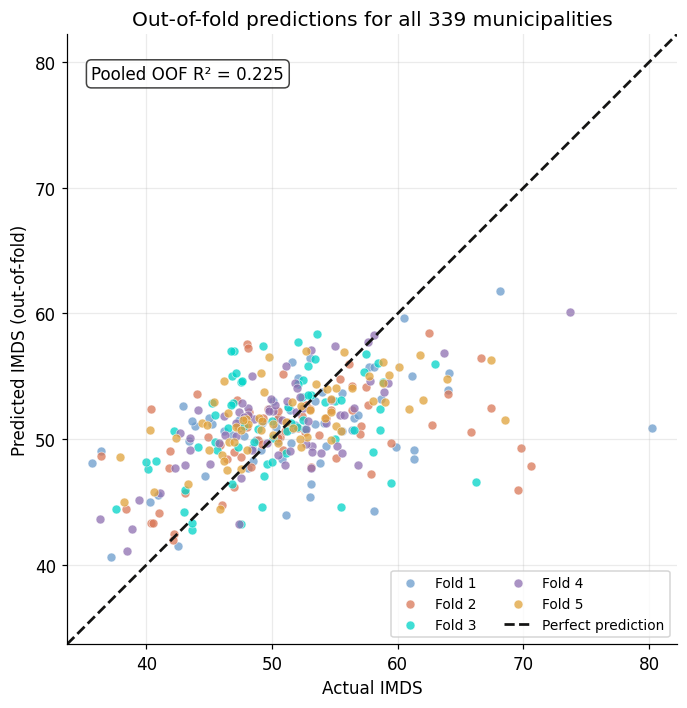

In [11]:
residuals = np.asarray(y) - oof_pred

fig, ax = plt.subplots(figsize=(7.2, 7.2))
for k in range(1, N_FOLDS + 1):
    m = fold_id == k
    ax.scatter(y[m], oof_pred[m], s=34, alpha=0.75, edgecolors="white",
               linewidth=0.4, color=FOLD_COLORS[k - 1], label=f"Fold {k}")
lims = [y.min() - 2, y.max() + 2]
ax.plot(lims, lims, "--", color=COLOR_DARK, linewidth=1.8, label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("Actual IMDS"); ax.set_ylabel("Predicted IMDS (out-of-fold)")
ax.set_title("Out-of-fold predictions for all 339 municipalities")
ax.text(0.04, 0.95, f"Pooled OOF R² = {pooled_r2:.3f}", transform=ax.transAxes,
        va="top", bbox=dict(boxstyle="round", fc="white", ec=COLOR_DARK, alpha=0.8))
ax.legend(loc="lower right", ncol=2, fontsize=9)
plt.savefig(IMAGES_DIR / "ml_actual_vs_predicted.png")
plt.show()

The fold colors are thoroughly intermingled — confirmation that shuffling mixed the municipalities well. More substantively, the cloud is flatter than the 45-degree line: low-IMDS municipalities are predicted too high and high-IMDS too low. The town with the highest actual IMDS (80.2) is predicted at only about 51. This **regression to the mean** is the fingerprint of a model with limited signal.

### 7.2 Residual analysis

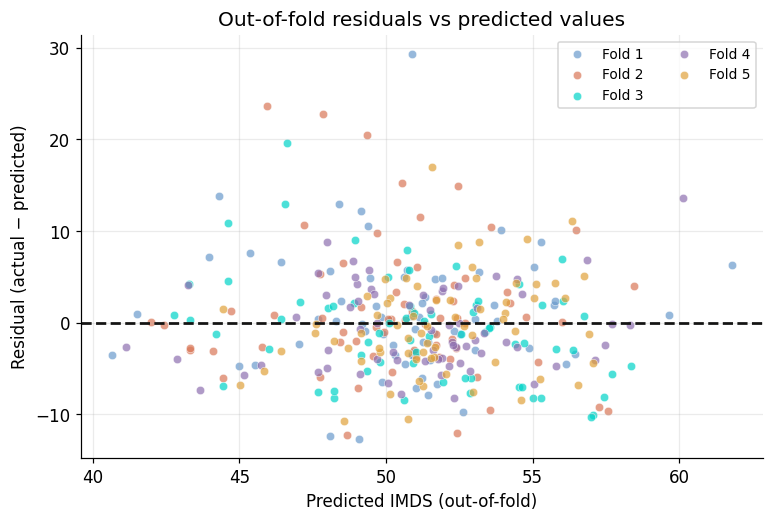

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in range(1, N_FOLDS + 1):
    m = fold_id == k
    ax.scatter(oof_pred[m], residuals[m], s=30, alpha=0.7, edgecolors="white",
               linewidth=0.4, color=FOLD_COLORS[k - 1], label=f"Fold {k}")
ax.axhline(0, color=COLOR_DARK, linestyle="--", linewidth=1.8)
ax.set_xlabel("Predicted IMDS (out-of-fold)"); ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Out-of-fold residuals vs predicted values")
ax.legend(loc="upper right", ncol=2, fontsize=9)
plt.savefig(IMAGES_DIR / "ml_residuals.png")
plt.show()

The cloud is centered near zero but tilts upward on the right, where the largest positive residuals sit — the high-IMDS municipalities the model under-predicts. The spread is also a little wider at the extremes (mild heteroscedasticity). The well-mixed colors confirm this is a property of the model, not one unlucky fold.

## 8. Comparing distributions — predicted vs actual

### 8.1 Overlapping histograms

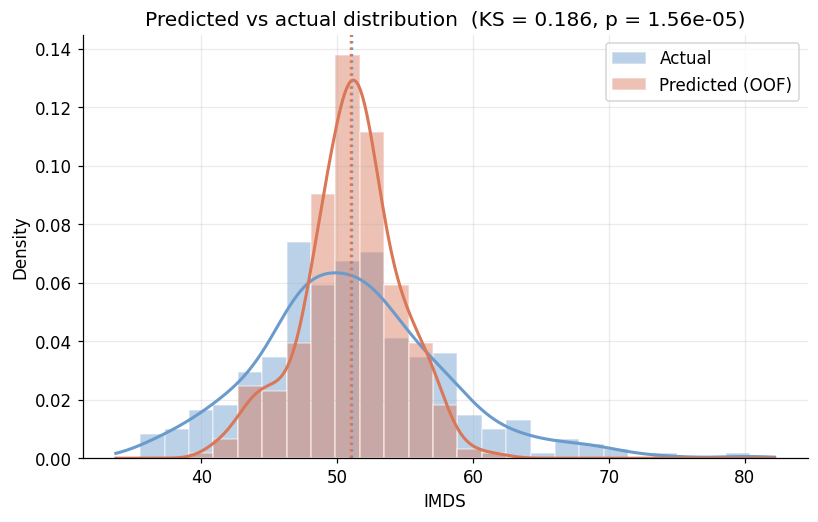

In [13]:
ks_stat, ks_p = ks_2samp(np.asarray(y), oof_pred)
bins = np.linspace(y.min() - 2, y.max() + 2, 28)
grid = np.linspace(y.min() - 2, y.max() + 2, 300)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(y, bins=bins, density=True, alpha=0.45, color=COLOR_PRIMARY, edgecolor="white", label="Actual")
ax.hist(oof_pred, bins=bins, density=True, alpha=0.45, color=COLOR_ACCENT, edgecolor="white", label="Predicted (OOF)")
ax.plot(grid, gaussian_kde(np.asarray(y))(grid), color=COLOR_PRIMARY, linewidth=2)
ax.plot(grid, gaussian_kde(oof_pred)(grid), color=COLOR_ACCENT, linewidth=2)
ax.axvline(y.mean(), color=COLOR_PRIMARY, linestyle=":", linewidth=1.6)
ax.axvline(oof_pred.mean(), color=COLOR_ACCENT, linestyle=":", linewidth=1.6)
ax.set_xlabel("IMDS"); ax.set_ylabel("Density")
ax.set_title(f"Predicted vs actual distribution  (KS = {ks_stat:.3f}, p = {ks_p:.3g})")
ax.legend()
plt.savefig(IMAGES_DIR / "ml_distribution_overlap.png")
plt.show()

The two distributions share almost the same center but very different widths. The predictions form a tall, narrow spike around 51 while the actual scores spread into both tails.

### 8.2 Summary statistics and a KS test

In [14]:
dist_stats = pd.DataFrame({
    "Statistic": ["Mean", "Std", "Min", "Max"],
    "Actual": [y.mean(), y.std(), y.min(), y.max()],
    "Predicted (OOF)": [oof_pred.mean(), oof_pred.std(), oof_pred.min(), oof_pred.max()],
}).round(2)
dist_stats.to_csv(TABLES_DIR / "ml_distribution_stats.csv", index=False)
print(dist_stats.to_string(index=False))
print(f"\nKS statistic = {ks_stat:.3f}  (p = {ks_p:.3g})")
print(f"Predicted SD is {100*(1-oof_pred.std()/y.std()):.0f}% smaller than actual SD")

Statistic  Actual  Predicted (OOF)
     Mean   51.05            51.02
      Std    6.77             3.54
      Min   35.70            40.66
      Max   80.20            61.79

KS statistic = 0.186  (p = 1.56e-05)
Predicted SD is 48% smaller than actual SD


The means match almost exactly (the model is unbiased on average), but the predicted standard deviation is only about half the actual, and the predicted range collapses inward. The KS test firmly rejects equal distributions. This **variance compression** is the mathematically expected behavior of any regression with modest $R^2$: a model that explains ~22% of the variance *should* produce predictions with much less spread than the truth. A good average and a good $R^2$ do not guarantee that predictions reproduce the real distribution — checking it is a quick, revealing diagnostic.

## 9. Which satellite features matter?

For interpretation we fit one baseline forest on all 339 municipalities (cross-validation already gave the honest performance estimate).

In [15]:
rf_full = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED).fit(X, y)

### 9.1 Mean decrease in impurity (MDI)

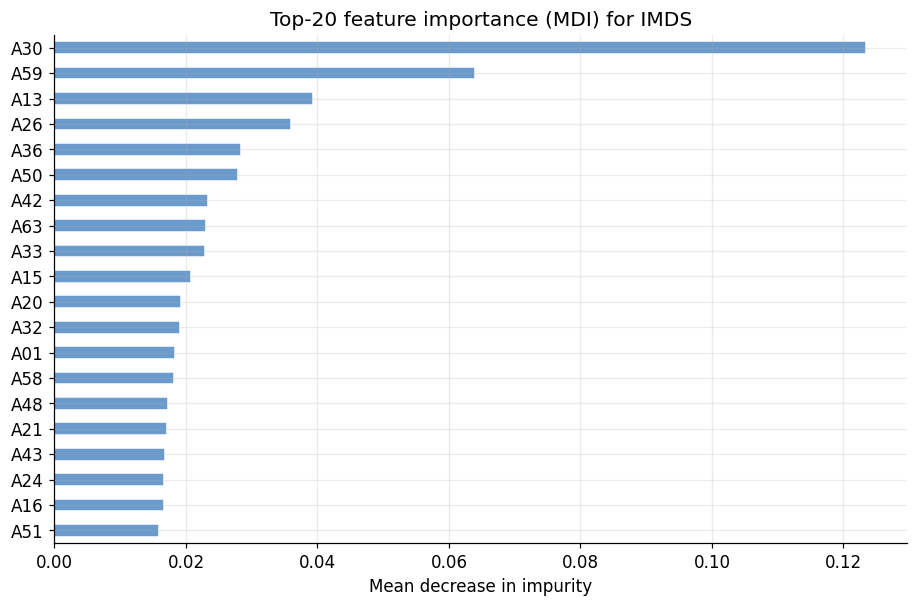

In [16]:
mdi = pd.Series(rf_full.feature_importances_, index=FEATURE_COLS)
top20 = mdi.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot.barh(ax=ax, color=COLOR_PRIMARY, edgecolor="white")
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Top-20 feature importance (MDI) for IMDS")
plt.savefig(IMAGES_DIR / "ml_feature_importance_mdi.png")
plt.show()

One dimension dominates: **A30** accounts for about 12% of the total impurity reduction, roughly twice the next feature, A59. After those two the importance falls into a long tail. This matches the correlation heatmap and tells us the forest leans on a small handful of visual signals.

### 9.2 Permutation importance

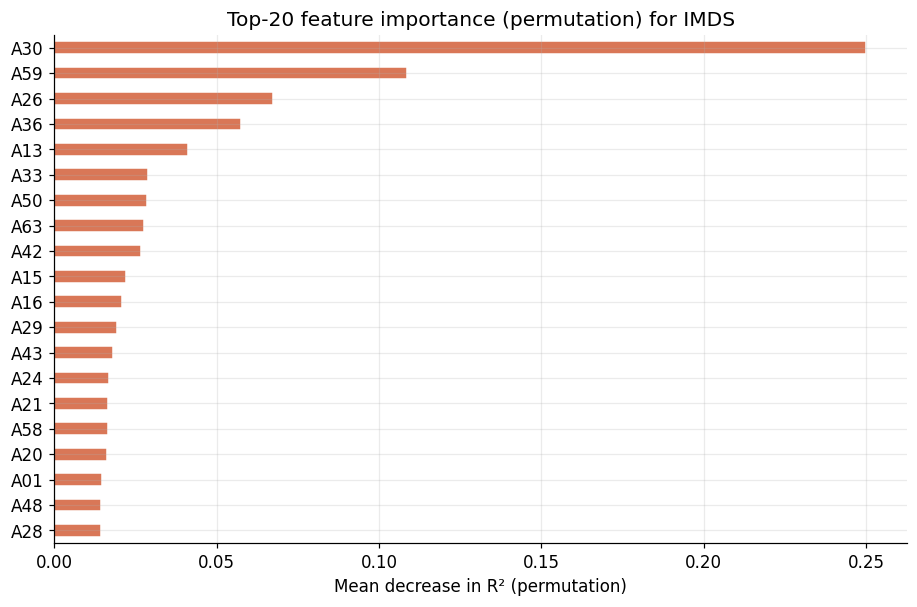

In [17]:
perm = permutation_importance(rf_full, X, y, n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURE_COLS)
top20 = perm_imp.sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot.barh(ax=ax, color=COLOR_ACCENT, edgecolor="white")
ax.set_xlabel("Mean decrease in R² (permutation)")
ax.set_title("Top-20 feature importance (permutation) for IMDS")
plt.savefig(IMAGES_DIR / "ml_feature_importance_permutation.png")
plt.show()

Shuffling **A30** alone costs about 0.25 in R² — larger than the model's entire OOF R², because removing the best feature drags the model below the mean-prediction baseline. A59 is again second, followed by A26, A36, A13. The close agreement between two very different methods is reassuring.

## 10. Partial dependence plots

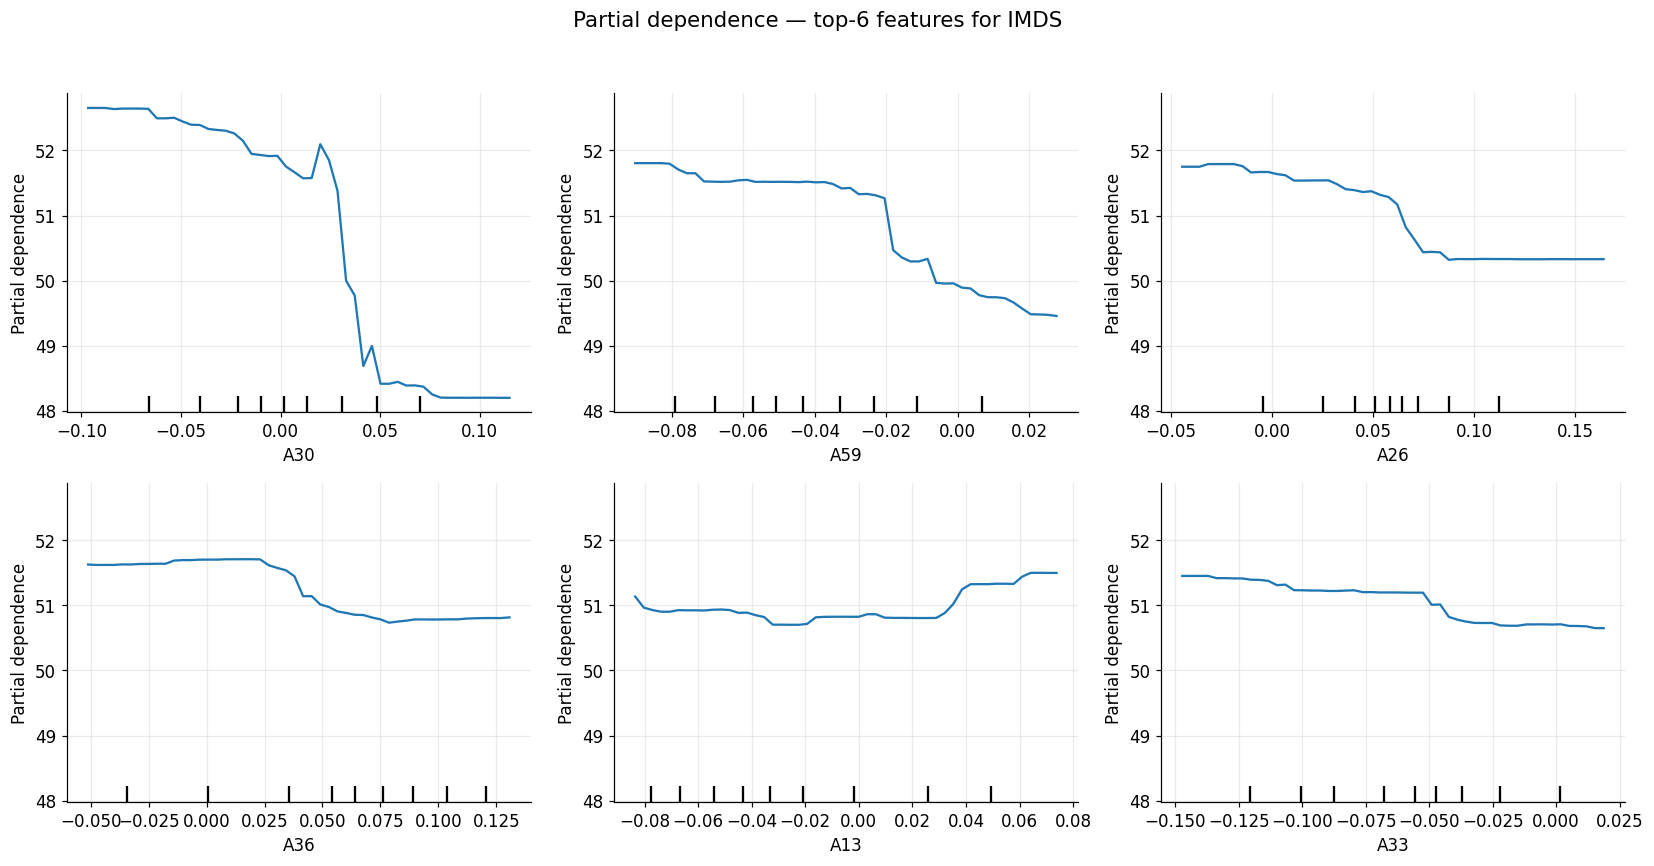

In [18]:
top6 = perm_imp.sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
PartialDependenceDisplay.from_estimator(rf_full, X, top6, ax=axes.ravel(), grid_resolution=50, n_jobs=-1)
fig.suptitle("Partial dependence — top-6 features for IMDS", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(IMAGES_DIR / "ml_partial_dependence.png")
plt.show()

The curves are clearly non-linear — several dimensions (A30 most visibly) show a threshold effect: flat, then a rise over a narrow band, then a plateau. These step-like shapes justify a Random Forest over a linear model. Even the most important feature moves the prediction by only a few IMDS points, consistent with the modest R².

## 11. Summary and key takeaways

In [19]:
summary = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Per-fold mean ± SD": [
        f"{fold_r2.mean():.3f} ± {fold_r2.std():.3f}",
        f"{fold_rmse.mean():.2f} ± {fold_rmse.std():.2f}",
        f"{fold_mae.mean():.2f} ± {fold_mae.std():.2f}"],
    "Pooled OOF": [f"{pooled_r2:.3f}", f"{rmse(y, oof_pred):.2f}", f"{mean_absolute_error(y, oof_pred):.2f}"],
})
summary.to_csv(TABLES_DIR / "ml_rf_results.csv", index=False)
Markdown(summary.to_markdown(index=False))

| Metric   | Per-fold mean ± SD   |   Pooled OOF |
|:---------|:---------------------|-------------:|
| R²       | 0.224 ± 0.173        |        0.225 |
| RMSE     | 5.86 ± 1.01          |        5.95  |
| MAE      | 4.42 ± 0.44          |        4.42  |

- **Cross-validation over a single split** gave an honest prediction for every municipality and a standard deviation that exposed how unstable the model is across slices of the country.
- **The spread matters.** Per-fold R² ranged from negative to ~0.45; reporting only the mean would mislead.
- **Data insight.** Satellite embeddings explain roughly a fifth of IMDS variation; A30 and A59 carry most of it, with non-linear threshold effects.
- **Distributions, not just points.** Predictions match the center but reproduce only half the spread (KS p < 0.001) — the expected behavior of a low-R² model.
- **Tuning is optional** — Appendix B shows it improves CV R² by less than the fold-to-fold noise.

## 12. Limitations and next steps

- **Modest R²** — much variation is driven by factors invisible from space (governance, migration, informal economy).
- **Variance compression** — predictions are pulled toward the mean, so the model cannot reliably rank the most extreme municipalities.
- **Temporal mismatch** — 2017 imagery vs SDG indices from a potentially different period.
- **Feature interpretability** — embedding dimensions (A00–A63) are abstract.
- **Small sample** — every estimate carries real uncertainty, which is why CV and its SD matter.

**Next steps:** combine embeddings with administrative/survey data, try gradient boosting, or use SHAP values.

## Appendix A — The train/test split approach

The classic alternative to cross-validation is a single 80/20 split — simpler and faster, and the right tool when data are plentiful.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)
single_split_r2 = r2_score(y_test, rf.predict(X_test))
print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print(f"Test R²: {single_split_r2:.3f}")

Train: 271  Test: 68
Test R²: 0.231


That number looks reassuringly close to the cross-validated 0.225 — but it is one draw from a lottery. We repeat the split under 200 seeds.

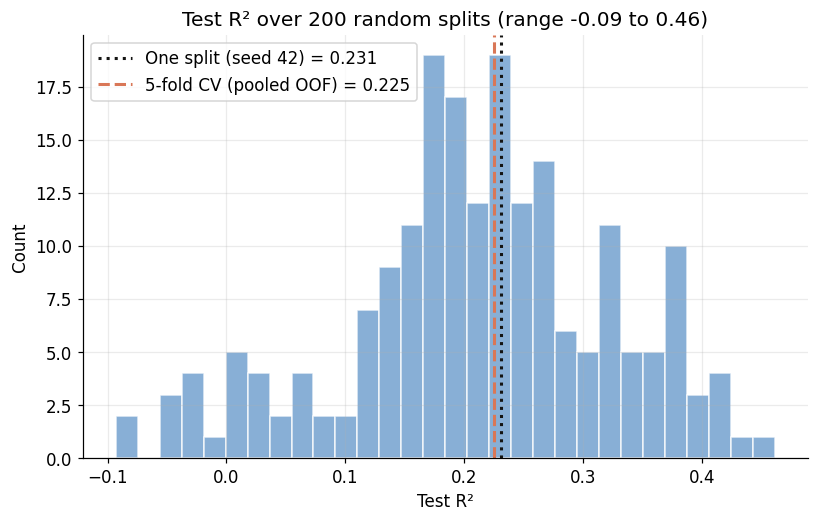

In [21]:
split_r2 = []
for seed in range(200):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    m = RandomForestRegressor(n_estimators=100, random_state=42).fit(Xtr, ytr)
    split_r2.append(r2_score(yte, m.predict(Xte)))
split_r2 = np.array(split_r2)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(split_r2, bins=30, color=COLOR_PRIMARY, alpha=0.8, edgecolor="white")
ax.axvline(single_split_r2, color=COLOR_DARK, linestyle=":", linewidth=2,
           label=f"One split (seed 42) = {single_split_r2:.3f}")
ax.axvline(pooled_r2, color=COLOR_ACCENT, linestyle="--", linewidth=2,
           label=f"5-fold CV (pooled OOF) = {pooled_r2:.3f}")
ax.set_xlabel("Test R²"); ax.set_ylabel("Count")
ax.set_title(f"Test R² over 200 random splits (range {split_r2.min():.2f} to {split_r2.max():.2f})")
ax.legend()
plt.savefig(IMAGES_DIR / "ml_appendix_split_variability.png")
plt.show()

The same model on the same data scores anywhere from about −0.09 to 0.46 depending only on which municipalities land in the test set. The cross-validated estimate sits sensibly in the middle, comes with a standard deviation, and uses every observation for both training and testing. On small datasets, be deeply suspicious of any number from a single split.

## Appendix B — Hyperparameter tuning: grid vs random vs Optuna

All three methods optimize the *same* 5-fold cross-validated R² (the `kf` from Section 5) over the *same* space, so they are directly comparable.

### B.1 Grid search

**Grid search** tries *every combination* of a discrete set of values — thorough and reproducible, but the number of fits explodes and it never sees values between grid points.

In [22]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid={"n_estimators": [100, 300], "max_depth": [None, 20], "max_features": ["sqrt", 1.0]},
    cv=kf, scoring="r2", n_jobs=-1,
).fit(X, y)
print(f"Grid best CV R²: {grid.best_score_:.3f}  {grid.best_params_}")

Grid best CV R²: 0.244  {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 300}


### B.2 Random search

**Random search** samples random combinations (including continuous ranges) for a fixed budget. For the same budget it usually beats grid search (Bergstra & Bengio, 2012): most hyperparameters barely matter, so random sampling spends more of its budget on the few that do.

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rand = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions={
        "n_estimators": [100, 200, 300, 500], "max_depth": [None, 10, 20, 30],
        "min_samples_split": randint(2, 11), "min_samples_leaf": randint(1, 5),
        "max_features": ["sqrt", "log2", 1.0]},
    n_iter=40, cv=kf, scoring="r2", random_state=42, n_jobs=-1,
).fit(X, y)
print(f"Random best CV R²: {rand.best_score_:.3f}  {rand.best_params_}")

Random best CV R²: 0.248  {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}


### B.3 Bayesian optimization with Optuna

Grid and random search are memoryless. **Optuna** is a Bayesian optimizer whose default **TPE** sampler builds a model of which regions score well and concentrates trials there. You write an `objective` that *suggests* a value for each hyperparameter and returns the score to maximize.

Optuna best CV R²: 0.251  {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


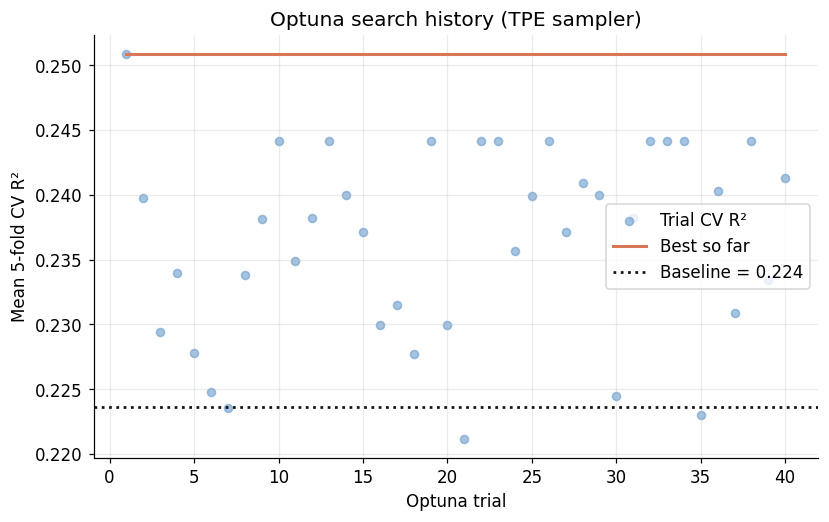

In [24]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import cross_val_score

baseline_cv_r2 = float(fold_r2.mean())

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=100),
        "max_depth": trial.suggest_categorical("max_depth", [None, 10, 20, 30]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
    }
    model = RandomForestRegressor(random_state=42, **params)
    return cross_val_score(model, X, y, cv=kf, scoring="r2", n_jobs=-1).mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40)
print(f"Optuna best CV R²: {study.best_value:.3f}  {study.best_params}")

trial_vals = np.array([t.value for t in study.trials if t.value is not None])
running_best = np.maximum.accumulate(trial_vals)
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(np.arange(1, len(trial_vals) + 1), trial_vals, s=28, alpha=0.6, color=COLOR_PRIMARY, label="Trial CV R²")
ax.plot(np.arange(1, len(trial_vals) + 1), running_best, color=COLOR_ACCENT, linewidth=2, label="Best so far")
ax.axhline(baseline_cv_r2, color=COLOR_DARK, linestyle=":", linewidth=1.8, label=f"Baseline = {baseline_cv_r2:.3f}")
ax.set_xlabel("Optuna trial"); ax.set_ylabel("Mean 5-fold CV R²")
ax.set_title("Optuna search history (TPE sampler)")
ax.legend()
plt.savefig(IMAGES_DIR / "ml_appendix_optuna_history.png")
plt.show()

### B.4 Did tuning help?

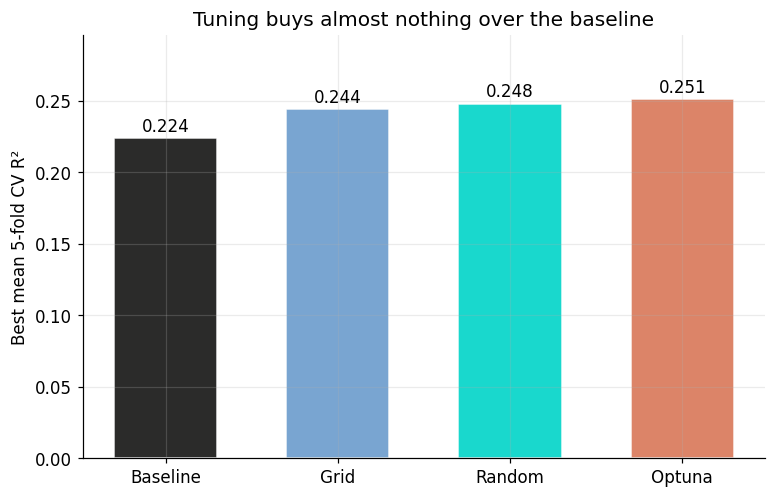

| Method   |   Best CV R2 |
|:---------|-------------:|
| Baseline |       0.2236 |
| Grid     |       0.2441 |
| Random   |       0.2478 |
| Optuna   |       0.2509 |

In [25]:
methods = ["Baseline", "Grid", "Random", "Optuna"]
scores = [baseline_cv_r2, float(grid.best_score_), float(rand.best_score_), float(study.best_value)]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, scores, color=[COLOR_DARK, COLOR_PRIMARY, COLOR_TEAL, COLOR_ACCENT],
              edgecolor="white", alpha=0.9, width=0.6)
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width() / 2, s + 0.002, f"{s:.3f}", ha="center", va="bottom")
ax.set_ylabel("Best mean 5-fold CV R²"); ax.set_ylim(0, max(scores) * 1.18)
ax.set_title("Tuning buys almost nothing over the baseline")
plt.savefig(IMAGES_DIR / "ml_appendix_tuning_comparison.png")
plt.show()

tuning_df = pd.DataFrame({"Method": methods, "Best CV R2": [round(s, 4) for s in scores]})
tuning_df.to_csv(TABLES_DIR / "ml_tuning_comparison.csv", index=False)
best = max([("Grid", grid.best_score_, grid.best_params_),
            ("Random", rand.best_score_, rand.best_params_),
            ("Optuna", study.best_value, study.best_params)], key=lambda t: t[1])
pd.DataFrame([{"Parameter": k, "Value": ("None" if v is None else v)} for k, v in best[2].items()]) \
    .to_csv(TABLES_DIR / "ml_rf_best_params.csv", index=False)
Markdown(tuning_df.to_markdown(index=False))

The methods rank as theory predicts (Optuna ≥ random ≥ grid for equal budgets), but the improvement is tiny — well within the fold-to-fold standard deviation from Section 6. The tuning gain is smaller than the noise, which is why the main analysis keeps the defaults. Spend effort on tuning when a baseline and a learning curve suggest there is headroom to win.

## Appendix C — Introduction to machine learning with multivariate regression

The main notebook used a Random Forest — a flexible black box across all 64 features. This appendix re-introduces the *same* workflow with the simplest model, **multiple linear regression**, on only the **first four features (A00–A03)**: a model you can write as one equation, evaluated with the identical 5-fold cross-validation, out-of-fold predictions, metrics, plots, importance, and partial dependence.

### C.1 The model — predict IMDS from four features

$\hat y = \beta_0 + \beta_1 A00 + \beta_2 A01 + \beta_3 A02 + \beta_4 A03$. Each coefficient is the change in predicted IMDS per one-unit change in that feature, holding the others fixed.

In [26]:
from sklearn.linear_model import LinearRegression

LR_FEATURES = FEATURE_COLS[:4]          # A00, A01, A02, A03
X4 = X[LR_FEATURES]
lr_full = LinearRegression().fit(X4, y)
print("intercept:", round(lr_full.intercept_, 2))
print({f: round(float(c), 2) for f, c in zip(LR_FEATURES, lr_full.coef_)})

intercept: 54.42
{'A00': 19.59, 'A01': -0.35, 'A02': 15.99, 'A03': 12.66}


Every term is visible and interpretable — but a model fit on all the data says nothing about generalization. For that we cross-validate.

### C.2 Five-fold cross-validation and out-of-fold predictions

In [27]:
lr = LinearRegression()
lr_cv = cross_validate(lr, X4, y, cv=kf,
                       scoring=("r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"))
lr_fold_r2 = lr_cv["test_r2"]
lr_fold_rmse = -lr_cv["test_neg_root_mean_squared_error"]
lr_fold_mae = -lr_cv["test_neg_mean_absolute_error"]
lr_oof = cross_val_predict(lr, X4, y, cv=kf)
lr_resid = np.asarray(y) - lr_oof
print("Per-fold R²:", lr_fold_r2.round(3))
print(f"Mean R²: {lr_fold_r2.mean():.3f} ± {lr_fold_r2.std():.3f}")
print(f"Pooled OOF R²: {r2_score(y, lr_oof):.3f}")

Per-fold R²: [ 0.054  0.071 -0.04   0.094  0.056]
Mean R²: 0.047 ± 0.046
Pooled OOF R²: 0.059


### C.3 Evaluating the predictions

In [28]:
lr_table = pd.DataFrame({
    "Fold": list(range(1, N_FOLDS + 1)) + ["Mean", "Std"],
    "R2": list(lr_fold_r2.round(3)) + [round(lr_fold_r2.mean(), 3), round(lr_fold_r2.std(), 3)],
    "RMSE": list(lr_fold_rmse.round(2)) + [round(lr_fold_rmse.mean(), 2), round(lr_fold_rmse.std(), 2)],
    "MAE": list(lr_fold_mae.round(2)) + [round(lr_fold_mae.mean(), 2), round(lr_fold_mae.std(), 2)],
})
Markdown(lr_table.to_markdown(index=False))

| Fold   |     R2 |   RMSE |   MAE |
|:-------|-------:|-------:|------:|
| 1      |  0.054 |   7.23 |  5.4  |
| 2      |  0.071 |   7.55 |  5.89 |
| 3      | -0.04  |   5.75 |  4.55 |
| 4      |  0.094 |   5.79 |  4.27 |
| 5      |  0.056 |   6.28 |  5    |
| Mean   |  0.047 |   6.52 |  5.02 |
| Std    |  0.046 |   0.74 |  0.58 |

The linear model explains only ~6% of IMDS variation — low, but the *workflow* is the lesson, not the score.

### C.4 Evaluation plots

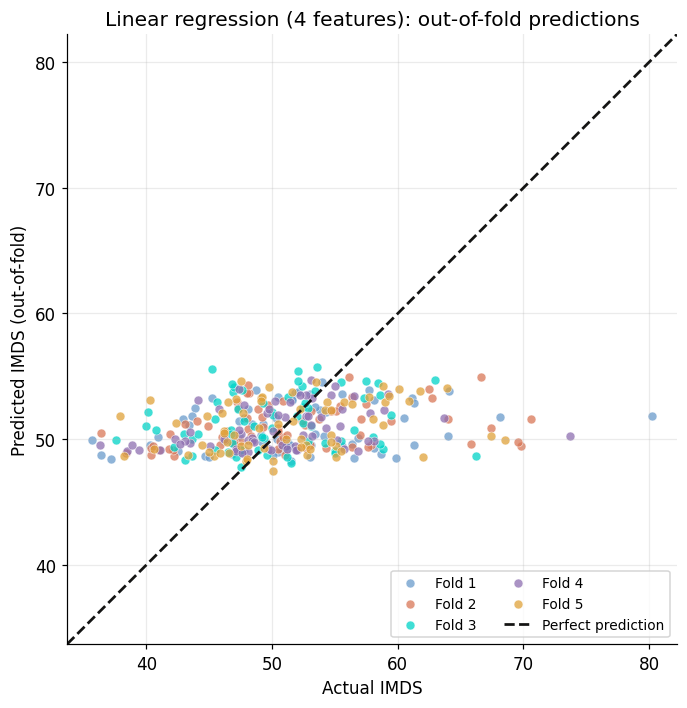

In [29]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))
for k in range(1, N_FOLDS + 1):
    m = fold_id == k
    ax.scatter(y[m], lr_oof[m], s=34, alpha=0.75, edgecolors="white", linewidth=0.4,
               color=FOLD_COLORS[k - 1], label=f"Fold {k}")
lims = [float(y.min()) - 2, float(y.max()) + 2]
ax.plot(lims, lims, "--", color="#141413", linewidth=1.8, label="Perfect prediction")
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
ax.set_xlabel("Actual IMDS"); ax.set_ylabel("Predicted IMDS (out-of-fold)")
ax.set_title("Linear regression (4 features): out-of-fold predictions")
ax.legend(loc="lower right", ncol=2, fontsize=9)
plt.savefig(IMAGES_DIR / "ml_lr_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

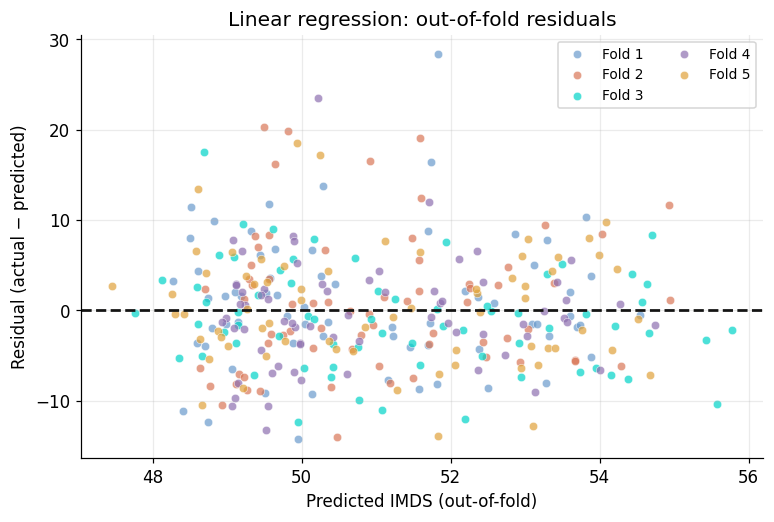

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
for k in range(1, N_FOLDS + 1):
    m = fold_id == k
    ax.scatter(lr_oof[m], lr_resid[m], s=30, alpha=0.7, edgecolors="white", linewidth=0.4,
               color=FOLD_COLORS[k - 1], label=f"Fold {k}")
ax.axhline(0, color="#141413", linestyle="--", linewidth=1.8)
ax.set_xlabel("Predicted IMDS (out-of-fold)"); ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Linear regression: out-of-fold residuals")
ax.legend(loc="upper right", ncol=2, fontsize=9)
plt.savefig(IMAGES_DIR / "ml_lr_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

With so little signal, predictions barely spread — almost every town is pulled to the mean of ~51.

### C.5 Feature importance

For a linear model, importance *is* the coefficient. Standardize the features so they are comparable; the standardized coefficient's magnitude is the importance and its sign the direction.

{'A00': 1.61, 'A01': -0.02, 'A02': 0.7, 'A03': 0.42}


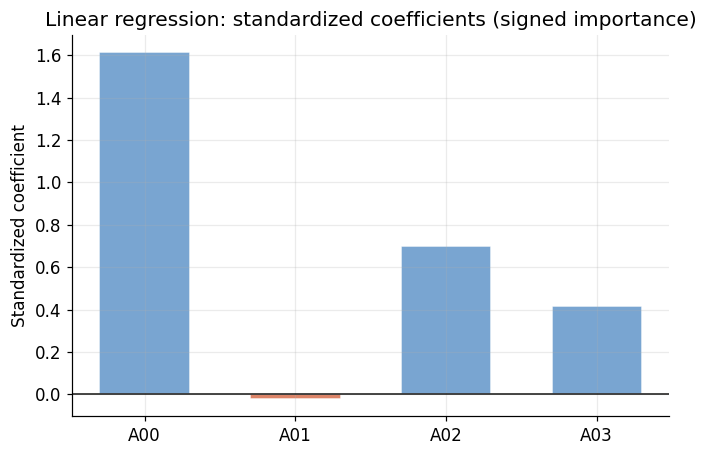

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

std = make_pipeline(StandardScaler(), LinearRegression()).fit(X4, y)
std_coefs = std[-1].coef_
print({f: round(float(c), 2) for f, c in zip(LR_FEATURES, std_coefs)})
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(LR_FEATURES, std_coefs,
       color=["#6a9bcc" if c >= 0 else "#d97757" for c in std_coefs],
       edgecolor="white", alpha=0.9, width=0.6)
ax.axhline(0, color="#141413", linewidth=1)
ax.set_ylabel("Standardized coefficient")
ax.set_title("Linear regression: standardized coefficients (signed importance)")
plt.savefig(IMAGES_DIR / "ml_lr_importance.png", dpi=300, bbox_inches="tight")
plt.show()

A00 dominates; A01 is essentially zero — the linear analogue of permutation importance, free and signed.

### C.6 Partial dependence

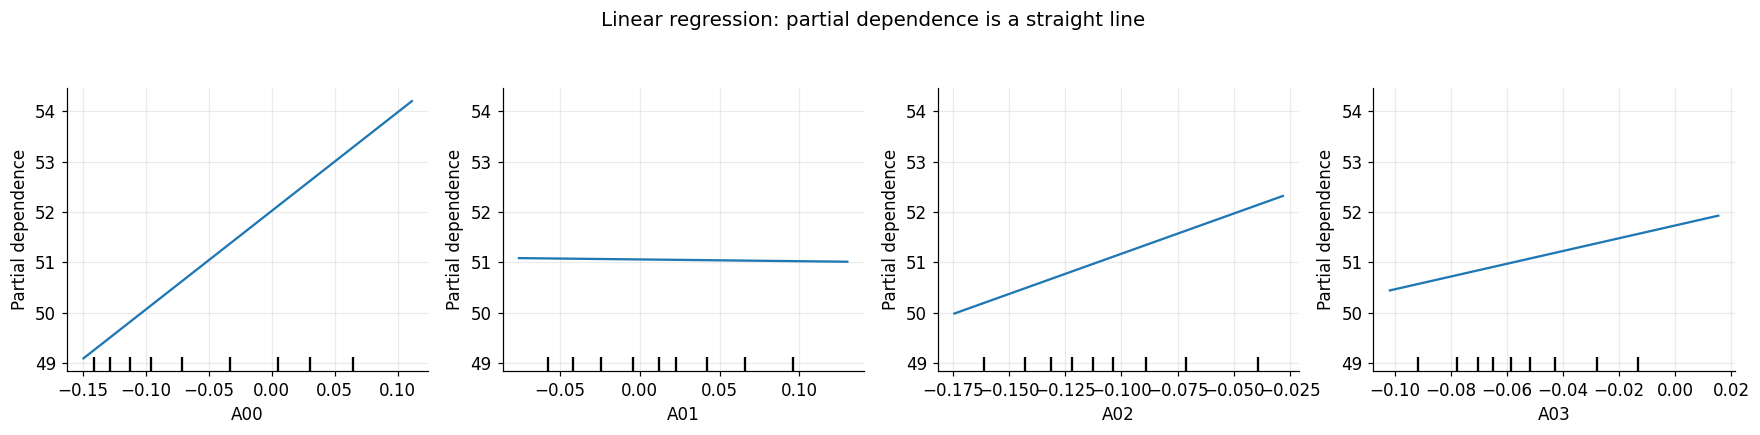

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
PartialDependenceDisplay.from_estimator(lr_full, X4, LR_FEATURES, ax=axes.ravel(), grid_resolution=50)
fig.suptitle("Linear regression: partial dependence is a straight line", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(IMAGES_DIR / "ml_lr_partial_dependence.png", dpi=300, bbox_inches="tight")
plt.show()

Every panel is a **straight line** — a linear model's effect is constant, the slope being the coefficient. Contrast the forest's bending curves (Section 11): that is what a flexible model buys you.

### C.7 How it compares to the Random Forest

Linear regression on 4 features reaches a pooled out-of-fold R² of about 0.06; the Random Forest on 64 features reaches 0.22 — roughly four times the explained variance, from more features and non-linearity. Yet both were built and judged with the *identical* workflow. Swapping `LinearRegression()` for `RandomForestRegressor()` is a one-line change.